<a href="https://colab.research.google.com/github/emmakelly7/A01-data-wrangling/blob/main/Data_Wrangling_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Emma Kelly

**Date:** 9/1/26

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('./data/airbnb_hw.csv')

In [ ]:
print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

df.head()

df.shape:
(30478, 13) 

df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 



,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '289' '179' '98' '195' '29' '27' '39'
 '249' '192' '142' '169' '1000' '131' '138' '113' '122' '329' '101' '475'
 '238' '272' '308' '126' '235' '315' '248' '128' '56' '207' '450' '215'
 '210' '385' '445' '136' '247' '118' '77' '76' '92' '198' '205' '299'
 '222' '245' '104' '153' '349' '114' '320' '292' '226' '420' '500' '325'
 '307' '78' '265' '108' '123' '189' '32' '58' '86' '219' '800' '335' '63'
 '229' '425' '67' '87' '1200' '158' '650' '234' '310' '695' '400' '166'
 '119' '62' '168' '340' '479' '43' '395' '144' '52' '47

<Axes: >

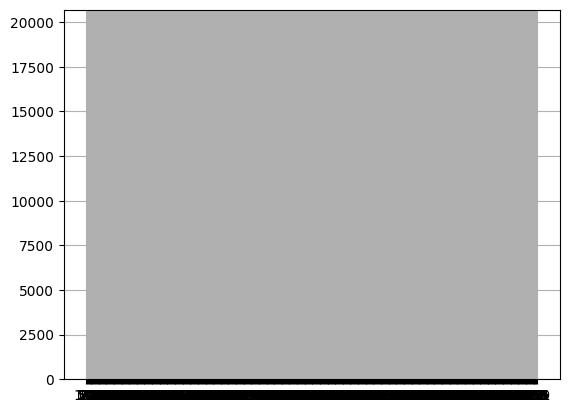

In [ ]:
var = 'Price'
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].str.replace(',', '')

print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')
df[var].hist()

In [ ]:
print('Before coercion:\n', df[var].describe(), '\n')

Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 



After coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total missings:
 0 



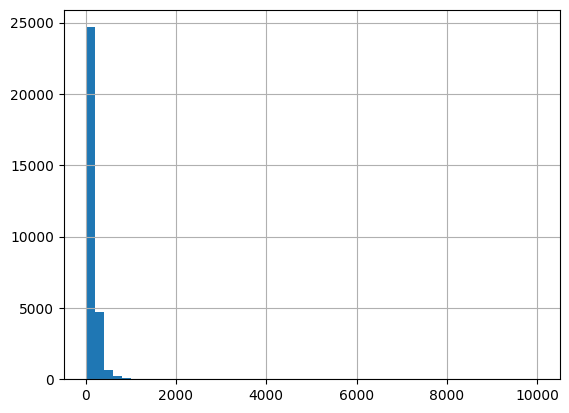

In [ ]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price_nan'] = df['Price'].isnull()

print('After coercion:\n', df[var].describe(), '\n')
df['Price'].hist(bins=50)
print('Total missings:\n', sum(df['Price_nan']), '\n')

Question 1 Part 1 Explanation: I tried to follow the class slides as closely as possible when cleaning the variable 'Price.' I replaced the variable name with the examples on the slides, and I used https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html to figure out how to strip units and separators based on the "Cleaning a Variable: Before" slide information. I did this because the slides said this made the "digits survive." I have no missing values, as I used str.replace with the data.

In [ ]:
df = pd.read_csv('./data/mn_police_use_of_force.csv')

print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

df.head()

df.shape:
(12925, 13) 

df.dtypes:
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 



,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 



<Axes: >

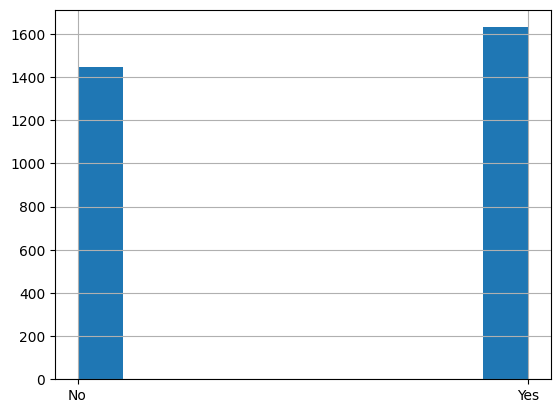

In [ ]:
var = 'subject_injury'
print (df[var].unique(), '\n')
print (df[var].value_counts(), '\n')
df[var].hist()

In [ ]:
df['subject_injury_nan'] = df['subject_injury'].isnull()
df['subject_injury'].isnull().sum()

np.int64(9848)

In [ ]:
9848 / 12925 * 100

76.19342359767892

In [ ]:
pd.crosstab(df['subject_injury'], df['force_type'])

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal Projectile,Police K9 Bite,Taser
subject_injury,,,,,,,,,
No,0,1093,131,2,33,34,1,2,150
Yes,2,1286,41,0,44,40,2,44,172


In [ ]:
pd.crosstab(df['subject_injury_nan'], df['force_type'])

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury_nan,,,,,,,,,,,
False,2,2379,172,2,77,74,0,3,0,46,322
True,2,7051,1421,0,27,74,87,0,170,31,985


Question One Part 2 Explanation: There should be 12925 values, but under Yes and No for subject_injury, there are 1631 and 1446 cases respectively. Then, I used df['subject_injury'].isnull().sum() to find that there are 9848 where subject_injury values are missing. I then calculated the percentage, which showed that 76.19% of the values are missing, which I would say is concerning. Then, I cross tabulated the cleaned subject_injury variable with the force_type variable using the instructions on the slides. Then, I cross tabulated with the missing-value indicator subject_injury_nan with force_type which showed True and False for if the subject_injury area was missing. There were patterns regarding when the data were missing. For bodily force, 7051 values were missing, and for chemical irritant, 1421 values were missing. This shows that there is an uneven spread of missing values depending on force_type.

In [ ]:
df = pd.read_excel('./data/GSAF5.xls')

In [ ]:
print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

df.head()

df.shape:
(7117, 23) 

df.dtypes:
Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
Unnamed: 21        object
Unnamed: 22        object
dtype: object 



,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['Unnamed: 21'].isnull().sum()

np.int64(7116)

In [ ]:
df['Unnamed: 22'].isnull().sum()

np.int64(7115)

In [ ]:
df[df['Unnamed: 21'].isnull() == False]

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
2274,13-Apr-2006,2006.0,Provoked,USA,Florida,"Port of the Islands, Collier County",Fishing,a sport fisherman,M,35,...,"Bull shark, 4' to bull shark","Naples News, 4/13/2006",2006.04.13-fisherman.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2006.04.13,2006.04.13,4839.0,stopped here,NaN


In [ ]:
df[df['Unnamed: 22'].isnull() == False]

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
5218,07-Jan-1952,1952.0,Unprovoked,AUSTRALIA,New South Wales,Evans Head,Surfing,Charles Thomas,M,NaN,...,8' shark,"Canberra Times, 1/8/1952",1952.01.07-CharlesThomas.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1952.01.07,1952.01.07,1895.0,NaN,Teramo
6646,02-Sep-1878,1878.0,Sea Disaster,SOUTH ATLANTIC OCEAN,Off the coast of West Africa,NaN,Boat with 5 men capsized while returning to th...,Antonio du Val,M,NaN,...,NaN,"Brisbane Courier, 11/19/1878",1878.09.02.b-Amerique-boy.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,1878.09.02.b,1878.09.02.b,468.0,NaN,change filename


In [ ]:
df = df.drop(columns=['Unnamed: 21', 'Unnamed: 22'])

In [ ]:
print(df.shape, '\n')
print(df.dtypes, '\n')

(7117, 21) 

Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
dtype: object 



[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914. 1913. 1912. 1911. 1910. 1909.
 1908. 1907. 1906. 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1897.
 1896. 1895. 1894. 1893. 1892. 1891. 1890. 1889. 1888. 1887. 1886. 1885.
 1884. 1883. 1882. 1881. 1880. 1879. 1878. 1877. 1876. 1875. 1874. 1873.
 1872. 1871. 1870. 1869. 1868. 1867. 1866. 1865. 18

<Axes: >

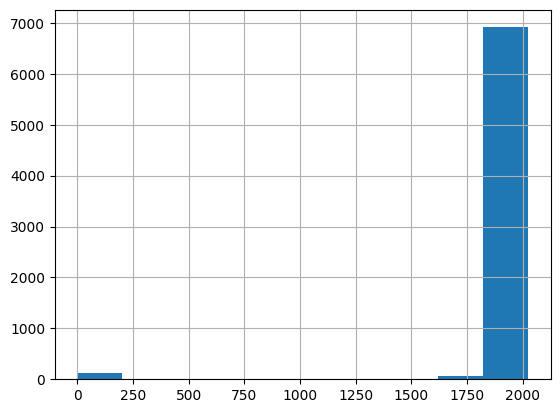

In [ ]:
var = 'Year'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')
df[var].hist()

In [ ]:
df = df[df['Year'] >= 1940]

count    5581.000000
mean     1992.668518
std        24.311209
min      1940.000000
25%      1970.000000
50%      2000.000000
75%      2013.000000
max      2026.000000
Name: Year, dtype: float64


<Axes: >

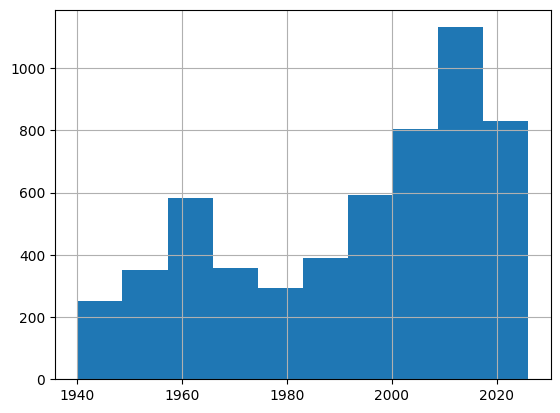

In [ ]:
print(df['Year'].describe())
df['Year'].hist()

After coercion:
 count    5581.000000
mean     1992.668518
std        24.311209
min      1940.000000
25%      1970.000000
50%      2000.000000
75%      2013.000000
max      2026.000000
Name: Year, dtype: float64 

Total missings:
 1936 



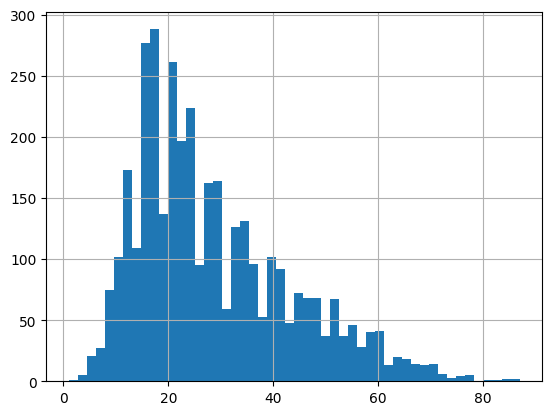

In [ ]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age_nan'] = df['Age'].isnull()

print('After coercion:\n', df[var].describe(), '\n')
df['Age'].hist(bins=50)
print('Total missings:\n', sum(df['Age_nan']), '\n')

[nan 43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 19. 11. 20. 38. 39. 16. 22.
 55. 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85. 18. 66.
 37. 42. 45. 30. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65. 64.
 32. 10. 62. 52. 44. 47. 59. 50. 34. 77. 73. 67.  6. 53. 51. 75. 70.  4.
 74.  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.] 

Age
17.0    151
20.0    141
15.0    141
19.0    137
18.0    137
       ... 
84.0      1
87.0      1
1.0       1
81.0      1
78.0      1
Name: count, Length: 82, dtype: int64 



<Axes: >

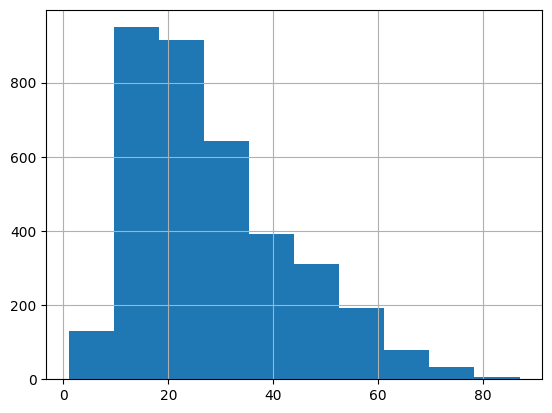

In [ ]:
var = 'Age'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')
df[var].hist()

In [ ]:
var = 'Sex'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')

['F' 'M' 'M ' 'M F' '?' 'F ' nan ' M' 'm' 'lli' 'M x 2'] 

Sex
M        4384
F         730
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64 



In [ ]:
4384 / 5581 * 100

78.5522307830138

In [ ]:
var = 'Type'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')

['Unprovoked' 'Provoked' 'Questionable' 'UNprovoked' 'unprovoked'
 ' Provoked' 'Watercraft' 'Sea Disaster' nan '?' 'Unconfirmed'
 'Unverified' 'Invalid' 'Under investigation' 'Boat'] 

Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
Boat                      7
 Provoked                 2
unprovoked                1
UNprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64 



In [ ]:
df['Type'] = df['Type'].replace({' Provoked': 'Provoked'})
df['Type'] = df['Type'].replace({'unprovoked': 'Unprovoked'})
df['Type'] = df['Type'].replace({'UNprovoked': 'Unprovoked'})
df['Type'] = df['Type'].fillna('Unknown')
df['Type'] = df['Type'].replace({'Questionable': 'Unknown'})
df['Type'] = df['Type'].replace({'Watercraft': 'Unknown'})
df['Type'] = df['Type'].replace({'Sea Disaster': 'Unknown'})
df['Type'] = df['Type'].replace({'?': 'Unknown'})
df['Type'] = df['Type'].replace({'Unconfirmed': 'Unknown'})
df['Type'] = df['Type'].replace({'Unverified': 'Unknown'})
df['Type'] = df['Type'].replace({'Invalid': 'Unknown'})
df['Type'] = df['Type'].replace({'Under investigation': 'Unknown'})
df['Type'] = df['Type'].replace({'Boat': 'Unknown'})

In [ ]:
var = 'Type'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')

['Unprovoked' 'Provoked' 'Unknown'] 

Type
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64 



In [ ]:
4163 / 5581 * 100

74.59236695932628

Question Two Explanation: I uploaded the data using df = pd.read_excel('./data/GSAF5.xls') because it's an Excel file. Then, I checked the data and found Unnamed 21 and Unnamed: 22, so I used .isnull().sum() for both to see if they were missing columns. I have 7117 total columns, so Unnamed: 21 has one missing and Unnamed: 22 has two missing. I then used boolean conditions to combine comparisons to see what those missing columns were. I then used https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html to figure out how to drop columns. I then checked to see if the columns dropped correctly. I then cleaned the Year variable and used boolean conditions to filter the rows to focus on attacks since 1940 because it had some impossible values. The data is meant to be on attacks since 1940, and this showed values from 0 to 2026. I then printed the shape again to see if the values were increasing or decreasing, and I found that they overall increased from around 1977 to around 2018 and then decreased. I then used pd.to_numeric to coerce the values because they were not being interpreted. I cleaned the Age variable and made a histogram of the ages of the victims, which ranged from 1 to 87. I found that 4384 victims were males and 730 were females. I calculated that 78.55% were males. I then used .replace again to change the values that were either misspelled or another reason to Provoked or Unprovoked or to Unknown. I then found the proportion to be 74.59% of unprovoked attacks.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]